In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv('sonar_knn.csv')

In [4]:
df.head()

,Freq_1,Freq_2,Freq_3,Freq_4,Freq_5,Freq_6,Freq_7,Freq_8,Freq_9,Freq_10,...,Freq_52,Freq_53,Freq_54,Freq_55,Freq_56,Freq_57,Freq_58,Freq_59,Freq_60,Label
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Freq_1   208 non-null    float64
 1   Freq_2   208 non-null    float64
 2   Freq_3   208 non-null    float64
 3   Freq_4   208 non-null    float64
 4   Freq_5   208 non-null    float64
 5   Freq_6   208 non-null    float64
 6   Freq_7   208 non-null    float64
 7   Freq_8   208 non-null    float64
 8   Freq_9   208 non-null    float64
 9   Freq_10  208 non-null    float64
 10  Freq_11  208 non-null    float64
 11  Freq_12  208 non-null    float64
 12  Freq_13  208 non-null    float64
 13  Freq_14  208 non-null    float64
 14  Freq_15  208 non-null    float64
 15  Freq_16  208 non-null    float64
 16  Freq_17  208 non-null    float64
 17  Freq_18  208 non-null    float64
 18  Freq_19  208 non-null    float64
 19  Freq_20  208 non-null    float64
 20  Freq_21  208 non-null    float64
 21  Freq_22  208 non

In [5]:
df['Label'].value_counts()

Label
M    111
R     97
Name: count, dtype: int64

In [8]:
df['Target']=df['Label'].map({'R':0,
                'M':1})

In [9]:
df['Target'].value_counts()

Target
1    111
0     97
Name: count, dtype: int64

### Train | Test Split

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X= df.drop(['Target','Label'],axis=1)
y= df['Label']

### Split the data into training and test set, with 90% for CV training and 10% for final test set

In [13]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.1,random_state=50)

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [15]:
scaler= StandardScaler()
knn= KNeighborsClassifier()

In [16]:
operations= (['scaler',scaler],['knn',knn])

In [17]:
from sklearn.pipeline import Pipeline

In [18]:
pipe= Pipeline(operations)

In [19]:
from sklearn.model_selection import GridSearchCV

In [20]:
k_values= list(range(1,30))

In [23]:
param_grid= {'knn__n_neighbors':k_values}

In [24]:
full_cv_classifier= GridSearchCV(pipe,param_grid,cv=5,scoring='accuracy')

In [25]:
full_cv_classifier.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=(['scaler', StandardScaler()],
                                       ['knn', KNeighborsClassifier()])),
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19,
                                              20, 21, 22, 23, 24, 25, 26, 27,
                                              28, 29]},
             scoring='accuracy')

In [26]:
full_cv_classifier.best_estimator_.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()),
  ['knn', KNeighborsClassifier(n_neighbors=3)]],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'knn': KNeighborsClassifier(n_neighbors=3),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'knn__algorithm': 'auto',
 'knn__leaf_size': 30,
 'knn__metric': 'minkowski',
 'knn__metric_params': None,
 'knn__n_jobs': None,
 'knn__n_neighbors': 3,
 'knn__p': 2,
 'knn__weights': 'uniform'}

In [27]:
full_cv_classifier.cv_results_['mean_test_score']

array([0.84992888, 0.79103841, 0.85049787, 0.80227596, 0.81294452,
       0.77567568, 0.75960171, 0.70611664, 0.73300142, 0.70071124,
       0.73812233, 0.71650071, 0.74338549, 0.73783784, 0.73769559,
       0.75391181, 0.74836415, 0.73769559, 0.73755334, 0.74295875,
       0.74836415, 0.73257468, 0.72716927, 0.73798009, 0.72176387,
       0.72176387, 0.72716927, 0.72731152, 0.73229018])

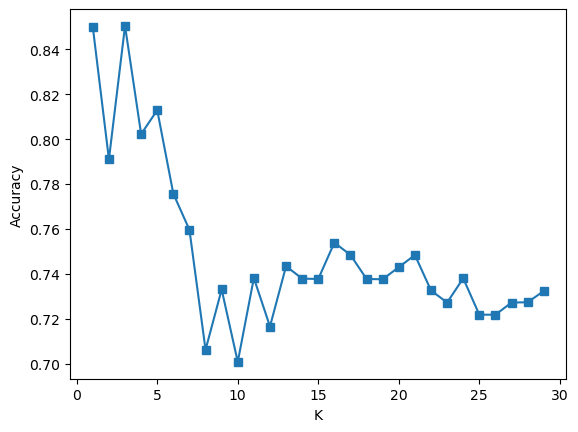

In [28]:
scores= full_cv_classifier.cv_results_['mean_test_score']

plt.plot(k_values,scores,'s-')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.show()

### Final Model Evaluation

In [29]:
pred= full_cv_classifier.predict(X_test)

In [30]:
from sklearn.metrics import classification_report,confusion_matrix

In [31]:
confusion_matrix(y_test,pred)

array([[12,  0],
       [ 2,  7]])

In [32]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           M       0.86      1.00      0.92        12
           R       1.00      0.78      0.88         9

    accuracy                           0.90        21
   macro avg       0.93      0.89      0.90        21
weighted avg       0.92      0.90      0.90        21

